In [1]:
import torch

from utils.checkpoints import load_ae_from_path, load_cspn_from_path, load_from_wandb
from utils.visualisation import (
    plot_latent_space,
    show,
)


In [2]:
ae_path = load_from_wandb("autoencoder_celeba")
ae = load_ae_from_path(ae_path, device=torch.device("mps"))

Loading checkpoint autoencoder_celeba:latest from Weights & Biases artifacts...


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.


Loaded /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_celeba_tcvae.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_celeba:latest


In [3]:
cspn_psi_path = load_from_wandb("cspn_celeba_single_attribute_psinet", "v2")
cspn_psi = load_cspn_from_path(cspn_psi_path, device=torch.device("mps"))

Loading checkpoint cspn_celeba_single_attribute_psinet:v2 from Weights & Biases artifacts...
Loaded /Users/jakob/Studium/Thesis/master-thesis/artifacts/cspn_celeba_single_attribute_psinet.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/cspn_celeba_single_attribute_psinet:v2


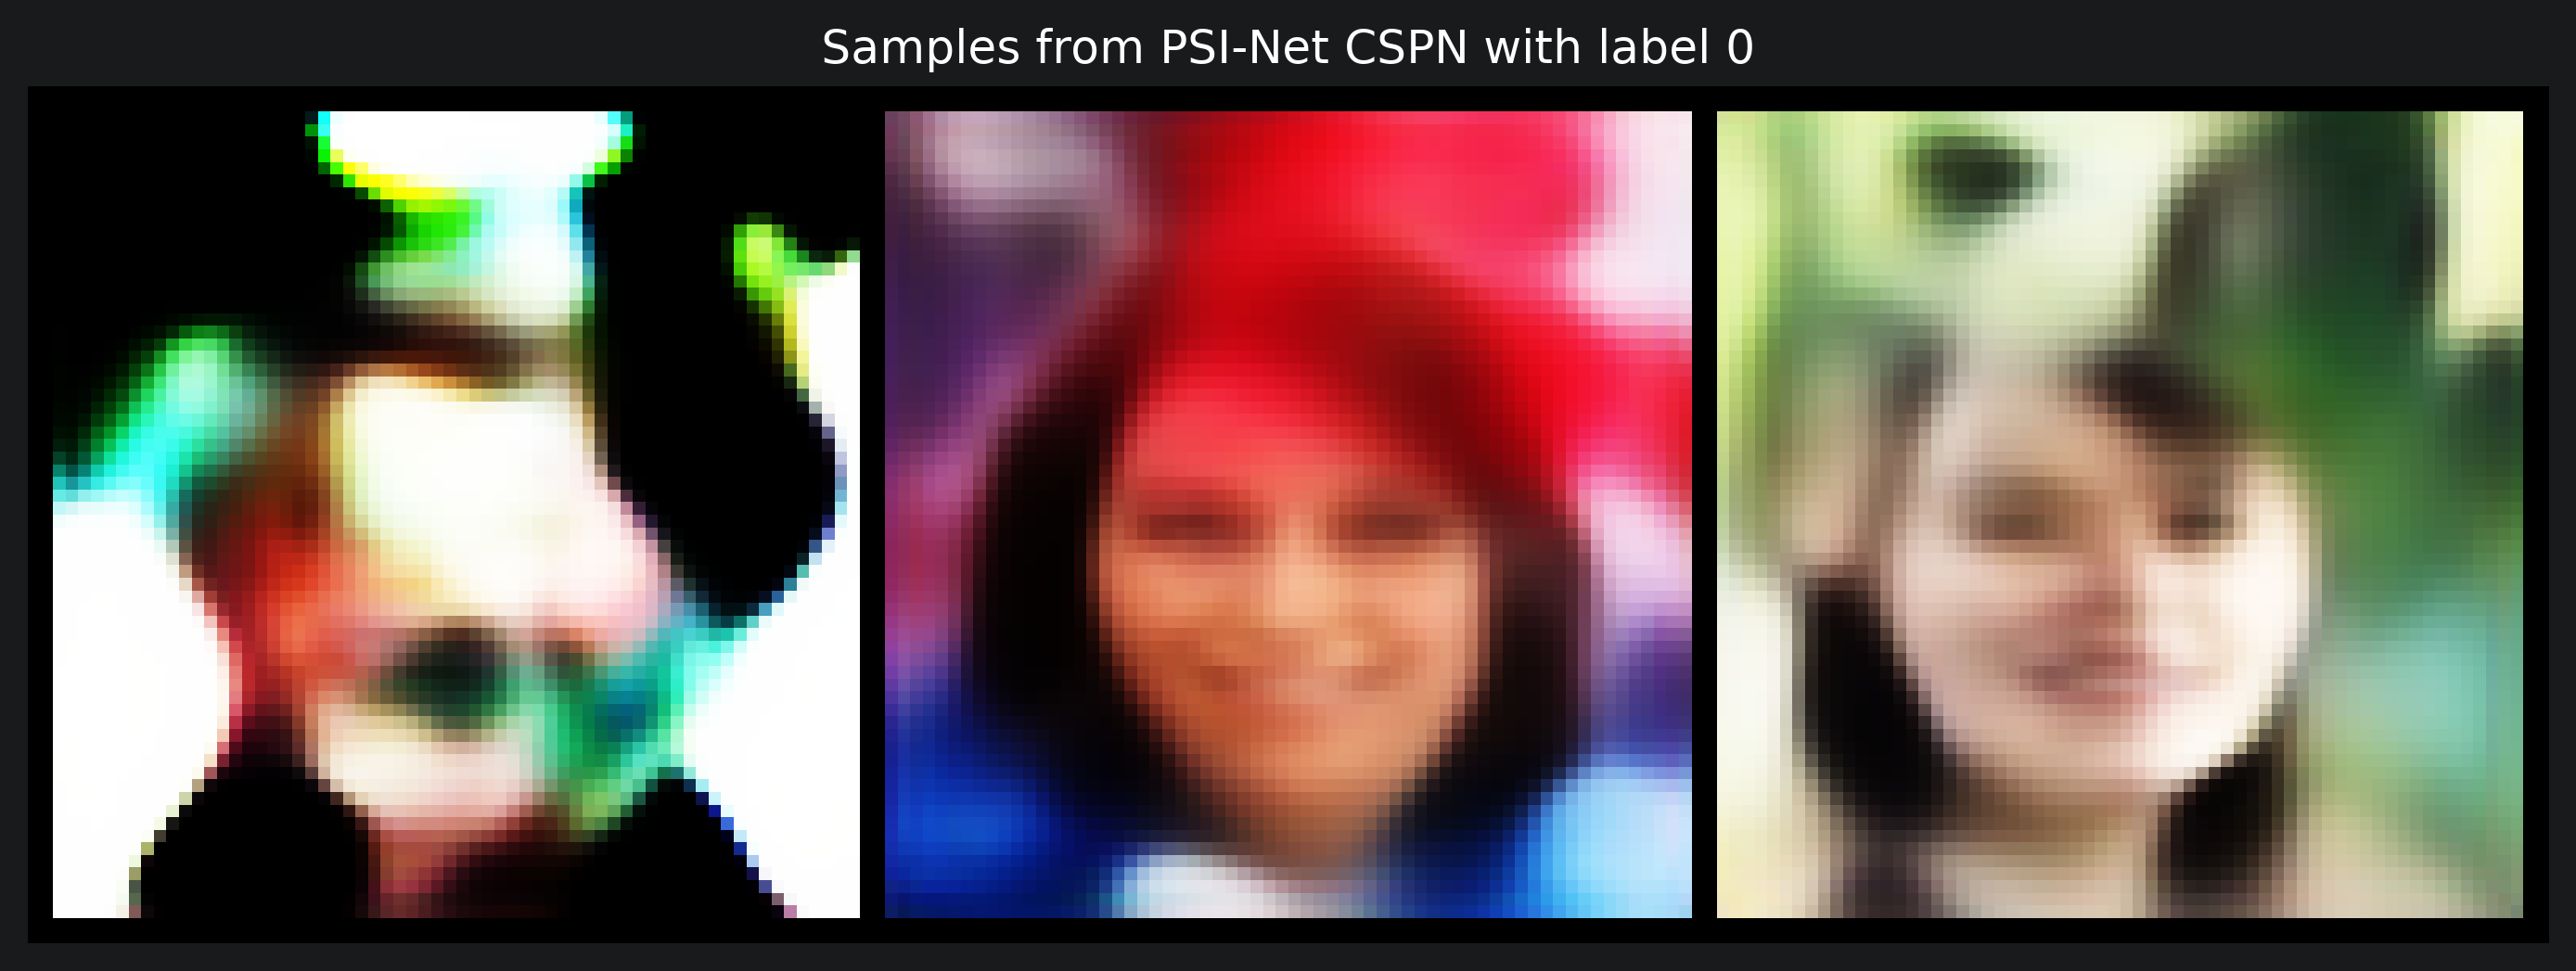

In [9]:
label = 0
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    samples_psi = cspn_psi.sample(sample_labels)
    sampled_images_psi_logits = ae.decode(samples_psi)
    sampled_images_psi = torch.sigmoid(sampled_images_psi_logits)

show(sampled_images_psi, f"Samples from PSI-Net CSPN with label {label}")

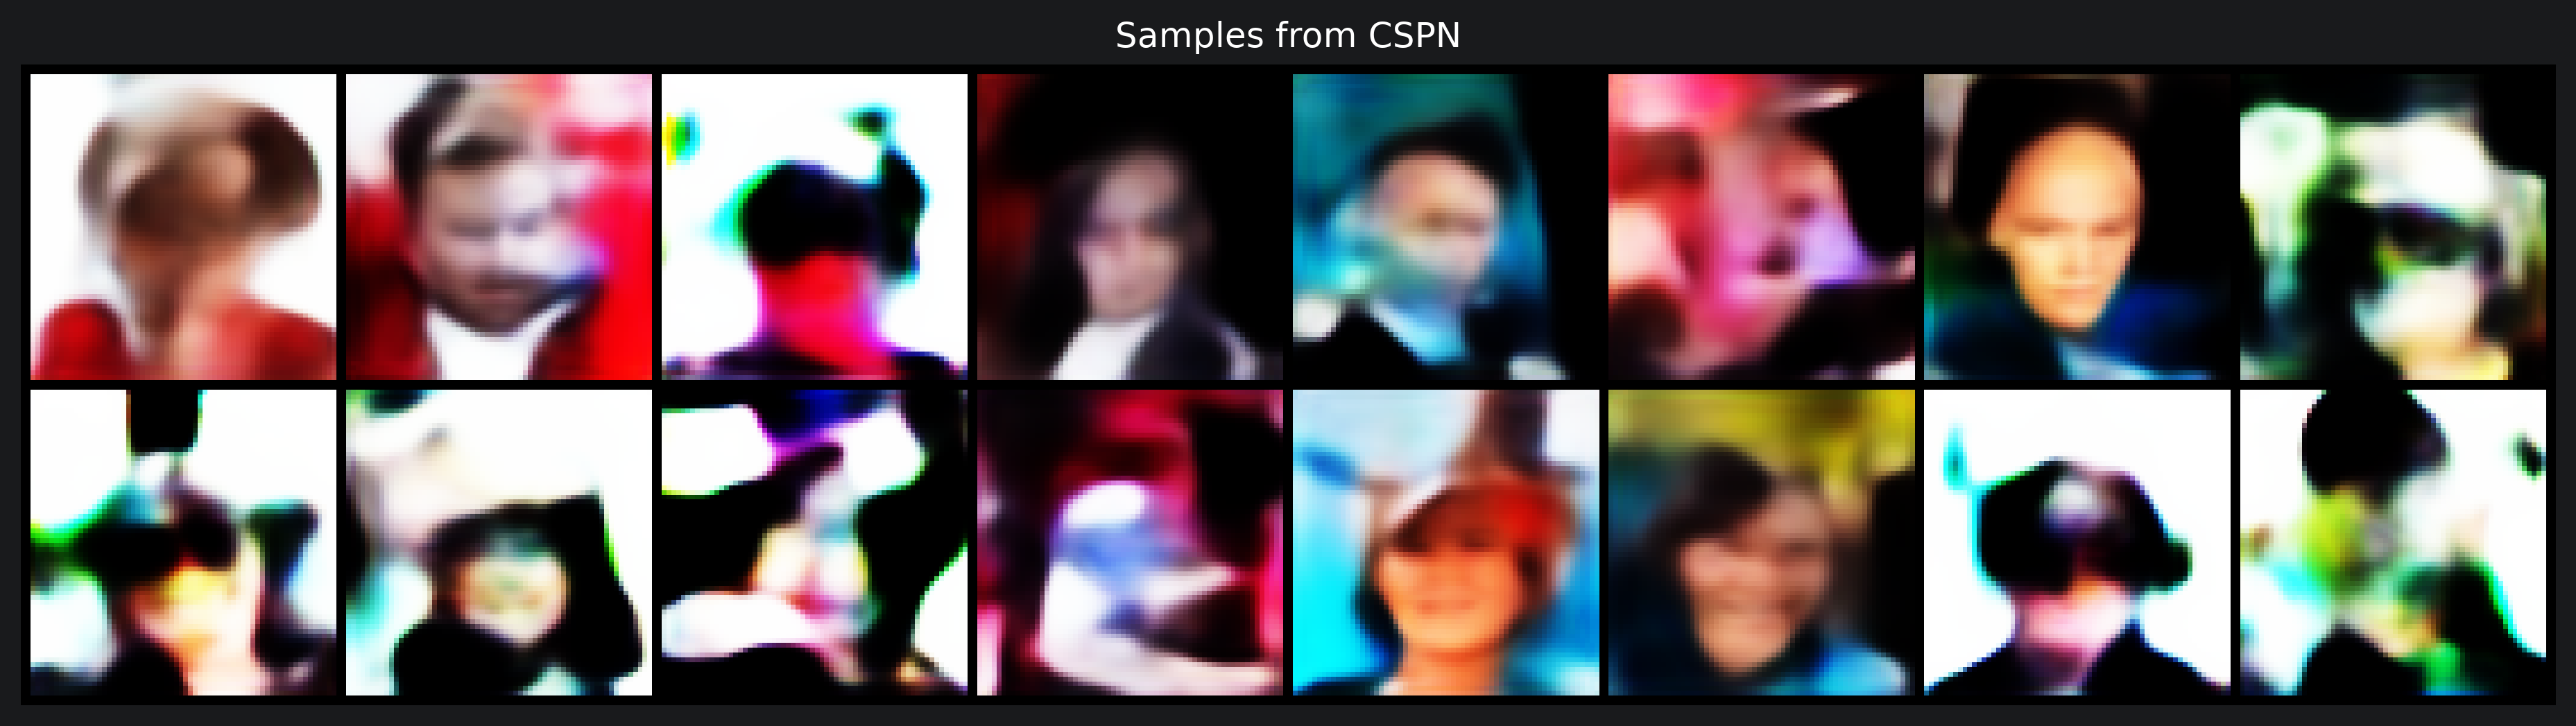

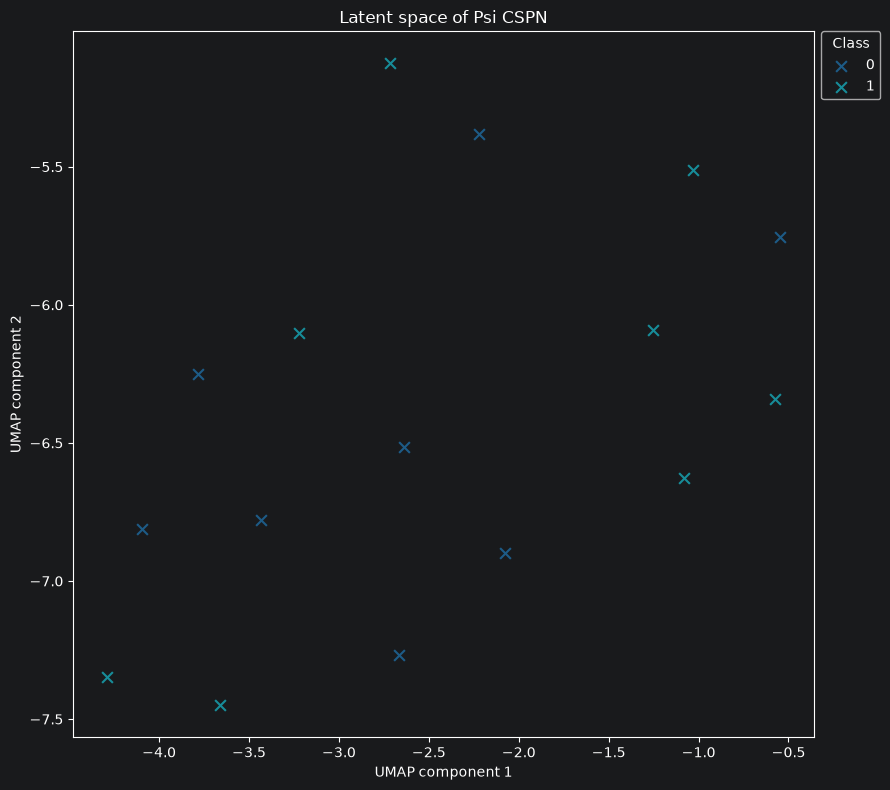

In [28]:
all_labels = torch.arange(2).repeat_interleave(8)

with torch.no_grad():
    samples_psi = cspn_psi.sample(all_labels)
    sampled_images_psi_logits = ae.decode(samples_psi)
    # sampled_images_psi = torch.sigmoid(sampled_images_psi_logits)

show(sampled_images_psi_logits, "Samples from CSPN", width=8)
plot_latent_space(samples_psi, all_labels, title="Latent space of Psi CSPN")

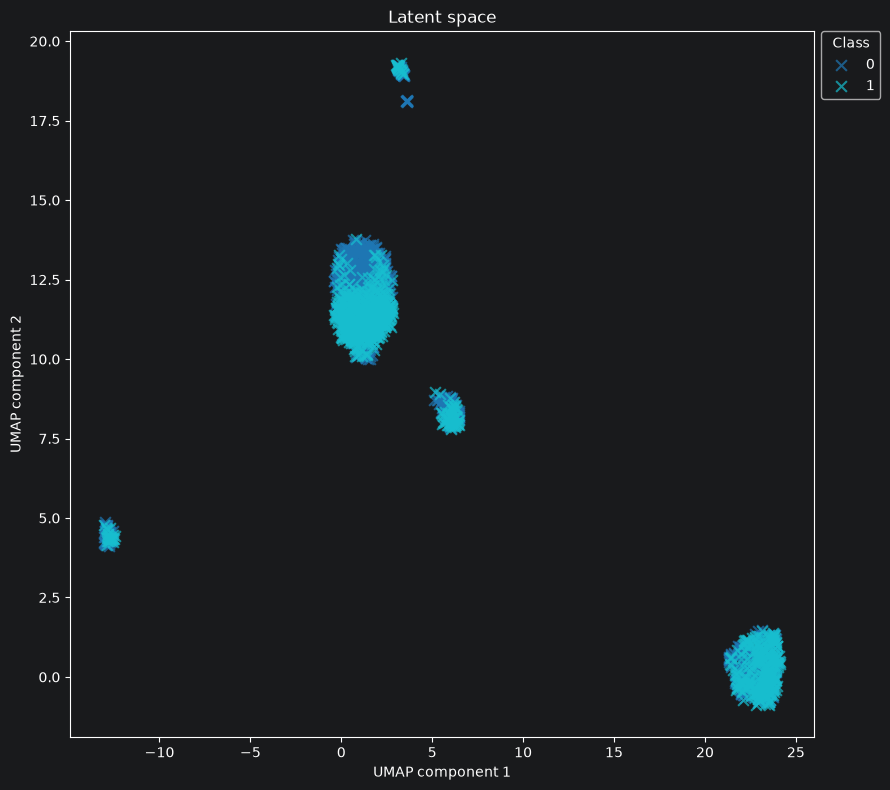

In [6]:
sample_multi_labels = torch.arange(0, 2).repeat_interleave(1000)
with torch.no_grad():
    samples_psi = cspn_psi.sample(sample_multi_labels)

plot_latent_space(samples_psi, sample_multi_labels)